In [2]:
import requests
import json
import csv
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [3]:
path = "..\services\detector_service\detections.csv"

bboxes = []

with open(path) as f:
    reader = csv.DictReader(f)
    for row in reader:
        bboxes.append([
            float(row["x1"]),
            float(row["y1"]),
            float(row["x2"]),
            float(row["y2"])
        ])


In [4]:
url = "http://localhost:8080/process-bboxes"

response = requests.post(url, json=bboxes)

print(response.json())

[[1014.3017380510305, 174.4444808887139, 1099.337016371343, 246.76267241703422], [193.86886700533813, 519.9923784751016, 350.574647034635, 624.1279375571329], [1092.1422921395838, 855.1845012615845, 1297.1574288583338, 1040.587211222522], [1613.5102765975012, 267.4951065756042, 1716.2544172225012, 362.2197159506042], [1410.760688742963, 2.6877602574254134, 1483.3367385476506, 52.67305555314074], [1198.725644078083, 39.78834450698048, 1282.925839390583, 127.29833138442189], [1199.7014115998084, 43.12941647579022, 1280.6852983185584, 127.42572308589764], [1020.9035402514749, 173.7540707321489, 1101.252966521006, 244.61213347628953], [205.70466573382237, 516.3793779320516, 361.5005489125333, 621.2494951195516], [1613.6357272718717, 272.49291869323304, 1715.4189303968717, 367.80801268737366], [1093.4333303912297, 866.8432038915357, 1294.5929983599797, 1050.190188754817], [1200.9324751910133, 45.21777570702099, 1283.5097456988258, 125.81304014183544], [1411.4262677347847, 1.8683732162896405

In [5]:
import numpy as np

shifted = response.json()
original = bboxes

original = np.array(original)
shifted = np.array(shifted)

offsets = shifted - original

offsets[:5]

array([[ 0.56516579, -0.68509675,  0.56516579, -0.68509675],
       [-0.70559589, -0.694206  , -0.70559589, -0.694206  ],
       [-0.25333774, -1.42829171, -0.25333774, -1.42829171],
       [-0.59738942, -0.82975304, -0.59738942, -0.82975304],
       [ 0.68305202,  0.16633787,  0.68305202,  0.16633787]])

In [6]:
w = offsets.flatten()

In [7]:
key = b"0123456789abcdef0123456789abcdef"
notKey = b"9876543210abcdef0123456789abcdef"

In [8]:
import hmac
import hashlib
import struct

def prng_scalar(key, label, idx, width, height):

    mac = hmac.new(key, digestmod=hashlib.sha256)

    mac.update(struct.pack(">Q", idx))
    mac.update(label.encode())

    mac.update(struct.pack(">d", width))
    mac.update(struct.pack(">d", height))

    digest = mac.digest()

    val = int.from_bytes(digest[:8], "big")

    return val/(2**64-1)

In [9]:
expected = []
expected_wrong = []

alpha = 0.01  # тот же параметр что в Go

for i,b in enumerate(original):

    x1,y1,x2,y2 = b

    width = x2-x1
    height = y2-y1

    rx = prng_scalar(key,"axis_x",i,width,height)
    ry = prng_scalar(key,"axis_y",i,width,height)

    sx = 2*rx - 1
    sy = 2*ry - 1

    dx = alpha*width*sx
    dy = alpha*height*sy

    expected.append(dx)
    expected.append(dy)
    
    rx_wrong = prng_scalar(notKey,"axis_x",i,width,height)
    ry_wrong = prng_scalar(notKey,"axis_y",i,width,height)
    
    sx_wrong = 2*rx_wrong - 1
    sy_wrong = 2*ry_wrong - 1

    dx_wrong = alpha*width*sx_wrong
    dy_wrong = alpha*height*sy_wrong

    expected_wrong.append(dx_wrong)
    expected_wrong.append(dy_wrong)

expected = np.array(expected)
expected_wrong = np.array(expected_wrong)
observed = offsets[:,0:2].flatten()

In [10]:
import scipy.stats as stats

T = np.dot(observed,expected) / (
    np.linalg.norm(observed)*np.linalg.norm(expected)
)

N = len(observed)

z = T*np.sqrt(N)

p_value = 2*(1-stats.norm.cdf(abs(z)))
print(z, p_value)

T_wrong = np.dot(observed,expected_wrong) / (
    np.linalg.norm(observed)*np.linalg.norm(expected_wrong)
)

z_wrong = T_wrong*np.sqrt(N)

p_value_wrong = 2*(1-stats.norm.cdf(abs(z_wrong)))
print(z_wrong, p_value_wrong)

152.78743403827426 0.0
-0.6260013078792336 0.5313140834747927


In [11]:
alpha = 0.05

if p_value < alpha:
    print("Watermark detected")
else:
    print("No watermark")

Watermark detected


In [12]:
if p_value_wrong < alpha:
    print("Wrong Watermark detected")
else:
    print("Wrong watermark was not detected")

Wrong watermark was not detected


In [13]:
import numpy as np
import hmac, hashlib, struct, os

# --- PRNG как в Go ---
def prng_scalar(key, label, idx, width, height):

    mac = hmac.new(key, digestmod=hashlib.sha256)

    mac.update(struct.pack(">Q", idx))
    mac.update(label.encode())

    mac.update(struct.pack(">d", width))
    mac.update(struct.pack(">d", height))

    digest = mac.digest()

    val = int.from_bytes(digest[:8], "big")

    return val/(2**64-1)


# --- ожидаемые сдвиги ---
def expected_shifts(key, boxes, alpha):

    exp = []

    for i,b in enumerate(boxes):

        x1,y1,x2,y2 = b

        width = x2-x1
        height = y2-y1

        rx = prng_scalar(key,"axis_x",i,width,height)
        ry = prng_scalar(key,"axis_y",i,width,height)

        sx = 2*rx - 1
        sy = 2*ry - 1

        dx = alpha*width*sx
        dy = alpha*height*sy

        exp.append(dx)
        exp.append(dy)

    return np.array(exp)


# --- matched detector ---
def detector_statistic(observed, expected):

    observed = observed - observed.mean()
    expected = expected - expected.mean()

    return np.dot(observed,expected) / (
        np.linalg.norm(observed)*np.linalg.norm(expected)
    )


# --- данные ---
observed = offsets[:,0:2].flatten()
alpha = 0.01

true_key = b"0123456789abcdef0123456789abcdef"

# статистика для правильного ключа
expected_true = expected_shifts(true_key, original, alpha)
T_true = detector_statistic(observed, expected_true)

print("True key statistic:",T_true)


# статистики для случайных ключей
random_stats = []

for i in range(200):

    key = os.urandom(32)

    exp = expected_shifts(key, original, alpha)

    T = detector_statistic(observed, exp)

    random_stats.append(T)

True key statistic: 1.0


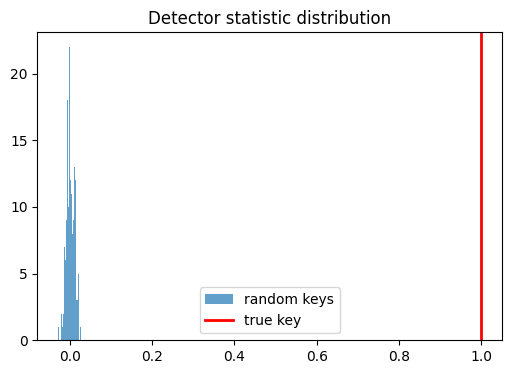

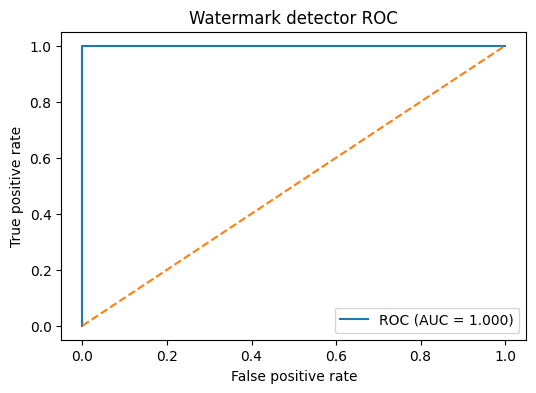

In [14]:
# --- распределение статистик ---
plt.figure(figsize=(6,4))

plt.hist(random_stats, bins=30, alpha=0.7, label="random keys")
plt.axvline(T_true, color="red", linewidth=2, label="true key")

plt.title("Detector statistic distribution")
plt.legend()
plt.show()


# --- ROC curve ---
labels = [1] + [0]*len(random_stats)
scores = [T_true] + random_stats

fpr,tpr,_ = roc_curve(labels, scores)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,4))

plt.plot(fpr,tpr,label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Watermark detector ROC")
plt.legend()

plt.show()

In [16]:
# ---------- ATTACKS ----------

def attack_noise(bboxes, sigma):
    
    noise = np.random.normal(0, sigma, bboxes.shape)
    
    return bboxes + noise


def attack_round(bboxes, decimals):

    return np.round(bboxes, decimals)


def attack_scale(bboxes, scale):

    return bboxes * scale


def attack_shift(bboxes, dx, dy):

    attacked = bboxes.copy()
    
    attacked[:,0] += dx
    attacked[:,2] += dx
    
    attacked[:,1] += dy
    attacked[:,3] += dy
    
    return attacked


def attack_prune(bboxes, keep_ratio):

    n = int(len(bboxes)*keep_ratio)
    
    idx = np.random.choice(len(bboxes), n, replace=False)
    
    return bboxes[idx]

In [17]:
def compute_detector_statistic(attacked_boxes, key, original_boxes, alpha=0.01):

    # offsets
    offsets = attacked_boxes - original_boxes

    # observed watermark signal
    observed = offsets[:,0:2].flatten()

    # expected watermark signal
    expected = expected_shifts(key, original_boxes, alpha)

    # detector statistic
    T = detector_statistic(observed, expected)

    return T

In [18]:
def evaluate_detector(attacked_boxes, key):

    T = compute_detector_statistic(attacked_boxes, key, original)

    return T

In [19]:
def random_key_stats(attacked_boxes, original_boxes, n=200):

    stats = []

    for _ in range(n):

        key = os.urandom(32)

        T = compute_detector_statistic(attacked_boxes, key, original_boxes)

        stats.append(T)

    return np.array(stats)

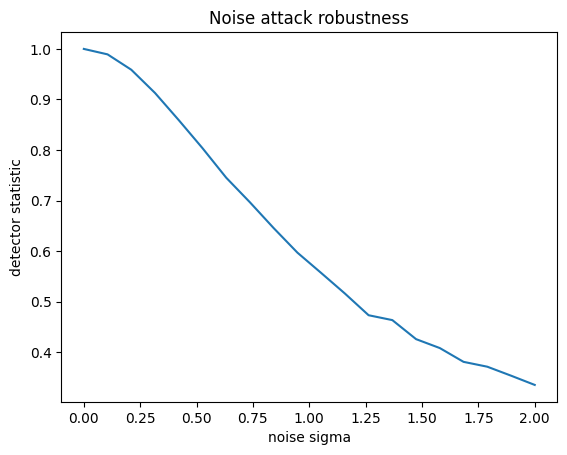

In [20]:
sigmas = np.linspace(0,2,20)

scores = []

for sigma in sigmas:

    attacked = attack_noise(shifted, sigma)

    T = compute_detector_statistic(attacked, true_key, original)

    scores.append(T)

plt.figure()

plt.plot(sigmas, scores)

plt.xlabel("noise sigma")
plt.ylabel("detector statistic")

plt.title("Noise attack robustness")

plt.show()

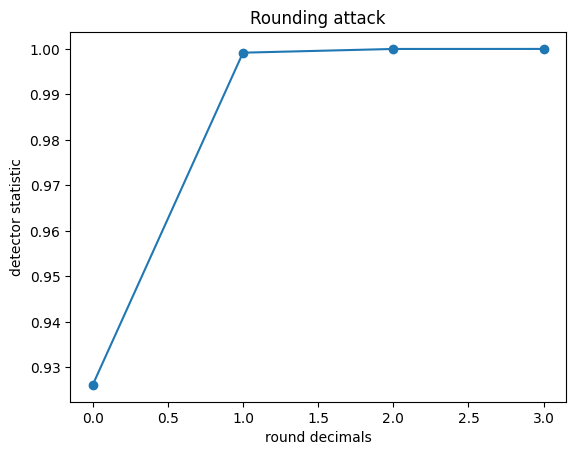

In [21]:
decimals_list = [3,2,1,0]

scores = []

for d in decimals_list:

    attacked = attack_round(shifted, d)

    T = compute_detector_statistic(attacked, true_key, original)

    scores.append(T)

plt.figure()

plt.plot(decimals_list, scores, marker='o')

plt.xlabel("round decimals")
plt.ylabel("detector statistic")

plt.title("Rounding attack")

plt.show()

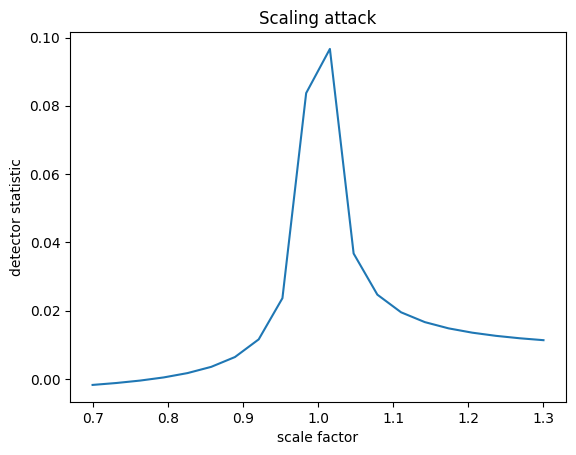

In [22]:
scales = np.linspace(0.7,1.3,20)

scores = []

for s in scales:

    attacked = attack_scale(shifted, s)

    T = compute_detector_statistic(attacked, true_key, original)

    scores.append(T)

plt.figure()

plt.plot(scales, scores)

plt.xlabel("scale factor")
plt.ylabel("detector statistic")

plt.title("Scaling attack")

plt.show()

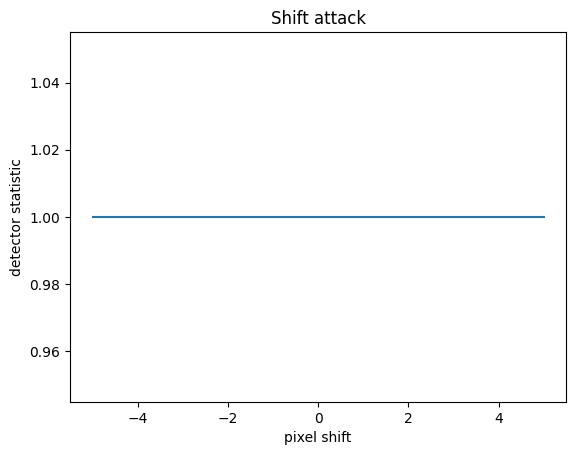

In [23]:
shifts = np.linspace(-5,5,20)

scores = []

for s in shifts:

    attacked = attack_shift(shifted, s, s)

    T = compute_detector_statistic(attacked, true_key, original)

    scores.append(T)

plt.figure()

plt.plot(shifts, scores)

plt.xlabel("pixel shift")
plt.ylabel("detector statistic")

plt.title("Shift attack")

plt.show()

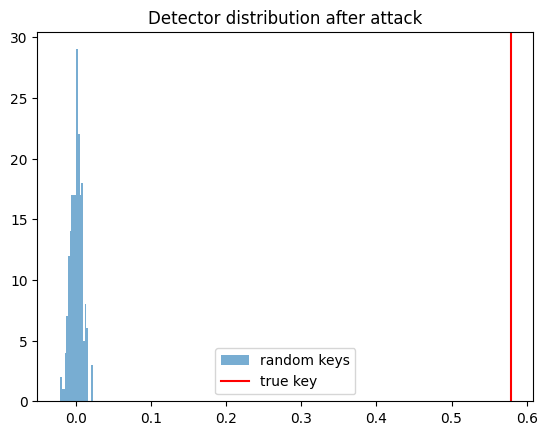

In [26]:
attacked = attack_noise(shifted, sigma=1.0)

true_stat = compute_detector_statistic(attacked, true_key, original)

rand_stats = random_key_stats(attacked, original)

plt.figure()

plt.hist(rand_stats, bins=20, alpha=0.6, label="random keys")

plt.axvline(true_stat, color="red", label="true key")

plt.legend()

plt.title("Detector distribution after attack")

plt.show()